In [1]:
!pip install -q -U watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.8 MB/s eta 0:00:00


In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np

# 1) Carrega o dataset
path = "/content/dataset.csv"  # Corrigido o caminho do arquivo
df = pd.read_csv(path)

# 2) Visão geral
n_rows, n_cols = df.shape
print(f"Linhas: {n_rows} | Colunas: {n_cols}")

missing = df.isna().sum()
dup_rows = df.duplicated().sum()
print("\nValores ausentes por coluna:")
print(missing)

print(f"\nLinhas duplicadas (idênticas): {dup_rows}")

# 3) Resumo por variável (tipo, ausentes, únicos)
summary_vars = pd.DataFrame({
    "Variável": df.columns,
    "Tipo": [df[c].dtype for c in df.columns],
    "Ausentes": [df[c].isna().sum() for c in df.columns],
    "Únicos": [df[c].nunique() for c in df.columns],
})

print("\nResumo das variáveis:")
print(summary_vars.to_string(index=False))

# 4) Checagens estruturais (opcional, mas bem útil)
# Cada mouse aparece quantas vezes?
id_counts = df["ID Mouse"].value_counts()
print("\nContagem de registros por ID Mouse (describe):")
print(id_counts.describe())

# Distribuição de timepoints
tp_counts = df["Timepoint"].value_counts().sort_index()
print("\nDistribuição de Timepoint:")
print(tp_counts)

# 5) Distribuição de variáveis categóricas
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    counts = df[col].value_counts()
    pct = (counts / len(df) * 100).round(1)
    print(f"\nDistribuição de {col}:")
    print(pd.DataFrame({"count": counts, "%": pct}))

# 6) Estatísticas descritivas das numéricas
num_cols = df.select_dtypes(include=[np.number]).columns
desc = df[num_cols].describe().T  # transposto para ficar "uma variável por linha"
print("\nEstatísticas descritivas (numéricas):")
print(desc)


Linhas: 500 | Colunas: 8

Valores ausentes por coluna:
ID Mouse               0
Medicamento            0
Sexo                   0
Idade_Meses            0
Peso (g)               0
Timepoint              0
Tumor Volume (mm3)     0
Sitios Metastáticos    0
dtype: int64

Linhas duplicadas (idênticas): 0

Resumo das variáveis:
           Variável    Tipo  Ausentes  Únicos
           ID Mouse  object         0     100
        Medicamento  object         0       4
               Sexo  object         0       2
        Idade_Meses   int64         0      24
           Peso (g)   int64         0      21
          Timepoint   int64         0       5
 Tumor Volume (mm3) float64         0     500
Sitios Metastáticos   int64         0       4

Contagem de registros por ID Mouse (describe):
count    100.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
Name: count, dtype: float64

Distribuição de Timepoint:
Timepoint
0     100
5     100
10    1

In [4]:
# Total de valores ausentes no dataset
total_missing = df.isna().sum().sum()
print(f"Total de valores ausentes no dataset: {total_missing}")

# Ausentes por coluna (e porcentagem)
missing_cols = df.isna().sum()
missing_report = pd.DataFrame({
    "Ausentes": missing_cols,
    "%": (missing_cols / len(df) * 100).round(2)
}).sort_values("Ausentes", ascending=False)

display(missing_report)

# (Opcional) Mostrar só colunas que têm ausentes
display(missing_report[missing_report["Ausentes"] > 0])


Total de valores ausentes no dataset: 0


,Ausentes,%
ID Mouse,0,0.0
Medicamento,0,0.0
Sexo,0,0.0
Idade_Meses,0,0.0
Peso (g),0,0.0
Timepoint,0,0.0
Tumor Volume (mm3),0,0.0
Sitios Metastáticos,0,0.0


,Ausentes,%


In [5]:
# Detecta strings vazias/espacos em colunas de texto
obj_cols = df.select_dtypes(include=["object"]).columns
vazios = {c: (df[c].astype(str).str.strip() == "").sum() for c in obj_cols}

vazios_df = pd.DataFrame.from_dict(vazios, orient="index", columns=["Strings vazias"]).sort_values("Strings vazias", ascending=False)
display(vazios_df)


,Strings vazias
ID Mouse,0
Medicamento,0
Sexo,0


In [6]:
# Verifica duplicidade considerando a chave (ID Mouse, Timepoint)
cols_key = ["ID Mouse", "Timepoint"]

dup_mask = df.duplicated(subset=cols_key, keep=False)
dup_rows = df[dup_mask].sort_values(cols_key)

print(f"Total de linhas duplicadas pela chave {cols_key}: {dup_mask.sum()}")

# Quantas chaves duplicadas (pares repetidos) existem
n_dup_keys = df.loc[dup_mask, cols_key].drop_duplicates().shape[0]
print(f"Total de chaves duplicadas (pares repetidos): {n_dup_keys}")

# Mostra as chaves duplicadas e a contagem de ocorrências
if dup_mask.any():
    dup_keys_counts = (
        df.loc[dup_mask, cols_key]
          .value_counts()
          .reset_index(name="ocorrencias")
          .sort_values("ocorrencias", ascending=False)
    )
    display(dup_keys_counts)
    print("\nLinhas duplicadas (detalhe):")
    display(dup_rows)
else:
    print("Não há duplicidade para essa combinação de colunas.")


Total de linhas duplicadas pela chave ['ID Mouse', 'Timepoint']: 0
Total de chaves duplicadas (pares repetidos): 0
Não há duplicidade para essa combinação de colunas.


In [7]:
# Seleciona apenas colunas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns

# Sumário estatístico solicitado
summary_stats = pd.DataFrame({
    "média": df[num_cols].mean(),
    "mediana": df[num_cols].median(),
    "variância": df[num_cols].var(),          # variância amostral (ddof=1)
    "desvio_padrão": df[num_cols].std()       # desvio padrão amostral (ddof=1)
}).round(4)

display(summary_stats)


,média,mediana,variância,desvio_padrão
Idade_Meses,12.4100,12.0000,49.2644,7.0189
Peso (g),19.9460,20.0000,36.3959,6.0329
Timepoint,10.0000,10.0000,50.1002,7.0781
Tumor Volume (mm3),40.0458,40.2379,20.1074,4.4841
Sitios Metastáticos,1.5220,2.0000,1.0636,1.0313


In [8]:
summary_stats_pop = pd.DataFrame({
    "média": df[num_cols].mean(),
    "mediana": df[num_cols].median(),
    "variância": df[num_cols].var(ddof=0),
    "desvio_padrão": df[num_cols].std(ddof=0)
}).round(4)

display(summary_stats_pop)


,média,mediana,variância,desvio_padrão
Idade_Meses,12.4100,12.0000,49.1659,7.0118
Peso (g),19.9460,20.0000,36.3231,6.0269
Timepoint,10.0000,10.0000,50.0000,7.0711
Tumor Volume (mm3),40.0458,40.2379,20.0672,4.4796
Sitios Metastáticos,1.5220,2.0000,1.0615,1.0303


In [9]:
# Sumário estatístico do Tumor Volume (mm3) por Medicamento
grp = df.groupby("Medicamento")["Tumor Volume (mm3)"]

summary_tumor_medic = pd.DataFrame({
    "n": grp.size(),
    "média": grp.mean(),
    "mediana": grp.median(),
    "variância": grp.var(),        # amostral (ddof=1)
    "desvio_padrão": grp.std()     # amostral (ddof=1)
}).round(4).sort_index()

summary_tumor_medic


,n,média,mediana,variância,desvio_padrão
Medicamento,,,,,
Capomulin,124,39.9529,40.1621,19.4854,4.4142
Infubinol,117,39.5276,39.5984,22.3069,4.7230
Placebo,126,40.2044,40.0729,22.4277,4.7358
Ramicane,133,40.4379,40.6830,16.5888,4.0729


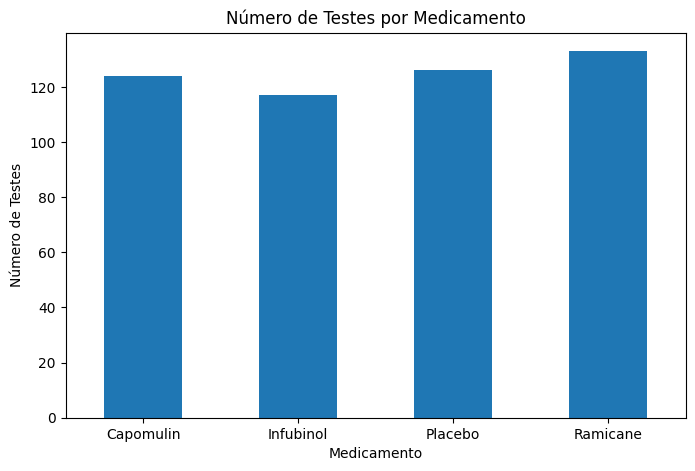

,count
Medicamento,
Capomulin,124
Infubinol,117
Placebo,126
Ramicane,133


In [10]:
import matplotlib.pyplot as plt

# Contagem de testes por medicamento
counts = df["Medicamento"].value_counts().sort_index()

# Gráfico
plt.figure(figsize=(8,5))
counts.plot(kind="bar")
plt.title("Número de Testes por Medicamento")
plt.xlabel("Medicamento")
plt.ylabel("Número de Testes")
plt.xticks(rotation=0)
plt.show()

counts


,Faixa Etária,n,média
0,0-6 meses,102,39.9831
1,6-12 meses,138,40.2186
2,12-18 meses,114,40.2815
3,18-24 meses,124,40.0133
4,24 meses ou mais,22,38.2134


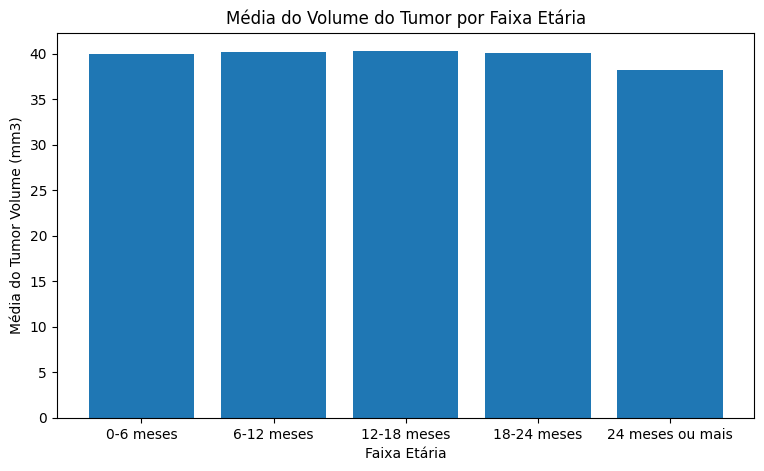

In [11]:
labels = ['0-6 meses', '6-12 meses', '12-18 meses', '18-24 meses', '24 meses ou mais']
bins = [0, 6, 12, 18, 24, np.inf]  # right=False faz o 24 cair em "24 meses ou mais"

df["Faixa Etária"] = pd.cut(
    df["Idade_Meses"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Tabela (contagem e média)
group_stats = (
    df.groupby("Faixa Etária")["Tumor Volume (mm3)"]
      .agg(n="size", média="mean")
      .reset_index()
)
group_stats["média"] = group_stats["média"].round(4)

display(group_stats)

# Gráfico
plt.figure(figsize=(9,5))
plt.bar(group_stats["Faixa Etária"], group_stats["média"])
plt.title("Média do Volume do Tumor por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Média do Tumor Volume (mm3)")
plt.xticks(rotation=0)
plt.show()


In [12]:
col = "Tumor Volume (mm3)"

def iqr_outlier_summary(group: pd.Series) -> pd.Series:
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = int(((group < lower) | (group > upper)).sum())
    return pd.Series(
        [q1, q3, iqr, lower, upper, outliers],
        index=["Q1", "Q3", "IQR", "limite_inferior", "limite_superior", "n_outliers"]
    )

tmp = df.groupby("Medicamento")[col].apply(iqr_outlier_summary)

outlier_resumo = tmp.unstack()
outlier_resumo["n_outliers"] = outlier_resumo["n_outliers"].astype(int)

for c in ["Q1","Q3","IQR","limite_inferior","limite_superior"]:
    outlier_resumo[c] = outlier_resumo[c].astype(float).round(4)

outlier_resumo


,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers
Medicamento,,,,,,
Capomulin,36.5963,42.9607,6.3644,27.0497,52.5073,0
Infubinol,35.5389,43.2630,7.7240,23.9529,54.8490,0
Placebo,36.9687,44.2766,7.3079,26.0069,55.2384,0
Ramicane,38.2118,43.0615,4.8496,30.9374,50.3359,2


In [13]:
# Filtra apenas o Timepoint máximo
max_tp = df["Timepoint"].max()
df_tpmax = df[df["Timepoint"] == max_tp].copy()

col = "Tumor Volume (mm3)"

def iqr_outlier_summary(group: pd.Series) -> pd.Series:
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = int(((group < lower) | (group > upper)).sum())
    return pd.Series(
        [q1, q3, iqr, lower, upper, outliers, group.size],
        index=["Q1", "Q3", "IQR", "limite_inferior", "limite_superior", "n_outliers", "n"]
    )

tmp = df_tpmax.groupby("Medicamento")[col].apply(iqr_outlier_summary)

outlier_resumo_tpmax = tmp.unstack()
outlier_resumo_tpmax["n_outliers"] = outlier_resumo_tpmax["n_outliers"].astype(int)
outlier_resumo_tpmax["n"] = outlier_resumo_tpmax["n"].astype(int)

for c in ["Q1","Q3","IQR","limite_inferior","limite_superior"]:
    outlier_resumo_tpmax[c] = outlier_resumo_tpmax[c].astype(float).round(4)

outlier_resumo_tpmax


,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,n
Medicamento,,,,,,,
Capomulin,33.0457,37.8978,4.8522,25.7674,45.1761,0,21
Infubinol,32.5633,36.4426,3.8793,26.7443,42.2616,0,34
Placebo,32.5021,37.6651,5.1630,24.7576,45.4096,0,26
Ramicane,33.5612,38.5651,5.0039,26.0554,46.0709,0,19


,média
Medicamento,
Capomulin,35.1844
Infubinol,34.8712
Placebo,35.1784
Ramicane,35.8645


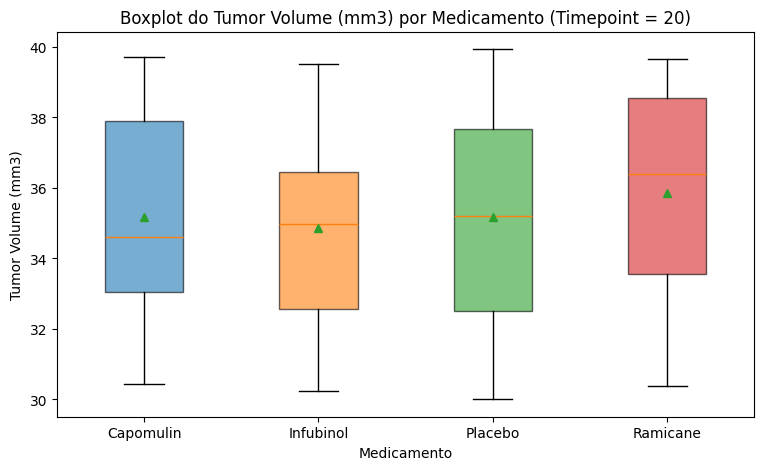

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Filtra apenas o Timepoint máximo
max_tp = df["Timepoint"].max()
df_tpmax = df[df["Timepoint"] == max_tp].copy()

col = "Tumor Volume (mm3)"

# Prepara dados (ordenados por nome do medicamento)
order = sorted(df_tpmax["Medicamento"].unique())
data = [df_tpmax.loc[df_tpmax["Medicamento"] == med, col].dropna().values for med in order]

# (Opcional) Tabela das médias (pra conferir)
means_df = (
    pd.DataFrame({"Medicamento": order, "média": [np.mean(v) for v in data]})
      .set_index("Medicamento")
      .round(4)
)
display(means_df)

# Boxplot com caixas preenchidas e média
fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    data,
    labels=order,
    patch_artist=True,
    showmeans=True
)

# Preenche as caixas usando o ciclo de cores padrão do matplotlib (contraste com fundo branco)
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(cycle_colors[i % len(cycle_colors)] if cycle_colors else None)
    box.set_alpha(0.6)

ax.set_title(f"Boxplot do Tumor Volume (mm3) por Medicamento (Timepoint = {max_tp})")
ax.set_xlabel("Medicamento")
ax.set_ylabel("Tumor Volume (mm3)")
plt.show()


,ID Mouse,Medicamento,Sexo,Idade_Meses,Peso (g),Timepoint,Tumor Volume (mm3),Sitios Metastáticos,Faixa Etária
0,m000,Placebo,Masculino,18,21,0,45.780350,2,18-24 meses
1,m000,Ramicane,Masculino,24,17,5,42.728114,0,24 meses ou mais
2,m000,Ramicane,Feminino,19,23,10,40.827502,1,18-24 meses
3,m000,Capomulin,Feminino,21,23,15,38.578206,2,18-24 meses
4,m000,Infubinol,Masculino,12,17,20,35.094393,2,12-18 meses


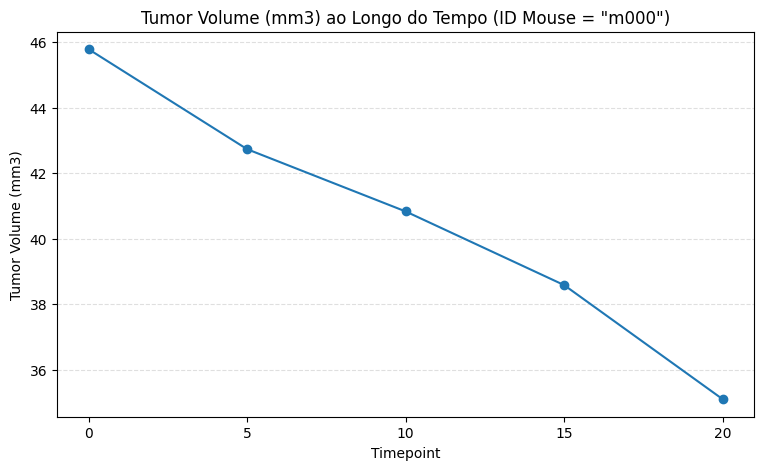

,Timepoint,Tumor Volume (mm3),Medicamento
0,0,45.7803,Placebo
1,5,42.7281,Ramicane
2,10,40.8275,Ramicane
3,15,38.5782,Capomulin
4,20,35.0944,Infubinol


In [15]:
# Filtra apenas o camundongo m000 e ordena pelo tempo
mouse_id = "m000"
df_m000 = df[df["ID Mouse"] == mouse_id].copy().sort_values("Timepoint")

display(df_m000)

# Gráfico de linha
plt.figure(figsize=(9,5))
plt.plot(df_m000["Timepoint"], df_m000["Tumor Volume (mm3)"], marker="o")
plt.title('Tumor Volume (mm3) ao Longo do Tempo (ID Mouse = "m000")')
plt.xlabel("Timepoint")
plt.ylabel("Tumor Volume (mm3)")
plt.xticks(df_m000["Timepoint"])
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.show()

# Tabela resumida (Timepoint, Volume do Tumor e Medicamento)
resumo_m000 = df_m000[["Timepoint", "Tumor Volume (mm3)", "Medicamento"]].copy()
resumo_m000["Tumor Volume (mm3)"] = resumo_m000["Tumor Volume (mm3)"].round(4)
display(resumo_m000)


N (camundongos Capomulin): 76
Equação: Tumor_médio = -0.1630 * Peso_médio + 43.1617
r = -0.2186 | r² = 0.0478 | p-value = 0.057824 | std_err = 0.084606


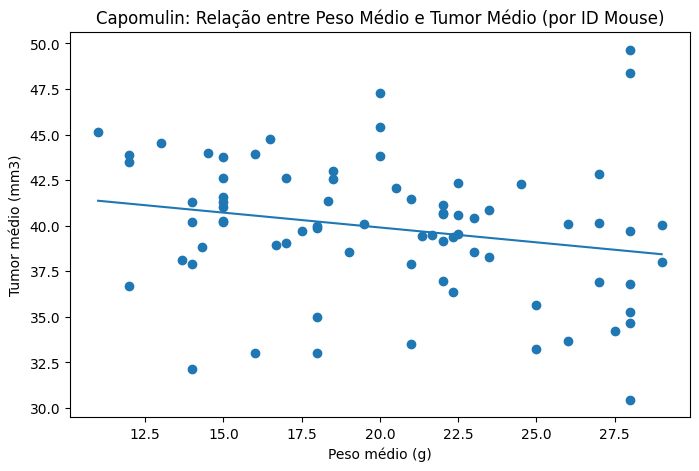

In [16]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

# 1) Filtra Capomulin
cap = df[df["Medicamento"] == "Capomulin"].copy()

# 2) Média por ID Mouse (peso e tumor)
agg = (cap.groupby("ID Mouse")
          .agg(peso_medio=("Peso (g)", "mean"),
               tumor_medio=("Tumor Volume (mm3)", "mean"))
          .reset_index())

# 3) Regressão linear (peso_medio -> tumor_medio)
x = agg["peso_medio"].values
y = agg["tumor_medio"].values

reg = linregress(x, y)
slope, intercept, r_value, p_value, std_err = reg.slope, reg.intercept, reg.rvalue, reg.pvalue, reg.stderr
r_squared = r_value**2

# 4) Resultados numéricos
print(f"N (camundongos Capomulin): {len(agg)}")
print(f"Equação: Tumor_médio = {slope:.4f} * Peso_médio + {intercept:.4f}")
print(f"r = {r_value:.4f} | r² = {r_squared:.4f} | p-value = {p_value:.6f} | std_err = {std_err:.6f}")

# 5) Scatter + linha de regressão
plt.figure(figsize=(8,5))
plt.scatter(x, y)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line)

plt.title("Capomulin: Relação entre Peso Médio e Tumor Médio (por ID Mouse)")
plt.xlabel("Peso médio (g)")
plt.ylabel("Tumor médio (mm3)")
plt.show()
